# Train/Test Split

In [3]:
import pandas as pd

df = pd.read_csv("../data/dataset_hanoi_window12.csv")

X = df.drop(columns=[
    "Scenario",
    "InjectionNode",
    "InjectionAmount",
    "Attack"
])

y = df["Attack"]



from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Attack"]
)

X_train = train_df.drop(columns=[
    "Scenario",
    "InjectionNode",
    "InjectionAmount",
    "Attack"
])

X_test = test_df.drop(columns=[
    "Scenario",
    "InjectionNode",
    "InjectionAmount",
    "Attack"
])

y_train = train_df["Attack"]

y_test = test_df["Attack"]

# Feature Scaling

In [4]:
#Feature Scalling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Train the Model For Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

#RANDOM FOREST

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1        # Use all CPU cores
)

model.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Prediction

In [6]:
y_pred = model.predict(X_test)

# Evaluation

In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9690411782386534
Precision: 0.9319727891156463
Recall   : 0.6707466340269278
F1 Score : 0.7800711743772242


# Performance Comparison of Different Sliding Window Sizes

      Metric  Window 4  Window 8  Window 12  Window 24
0   Accuracy     96.83     97.00      97.41      98.12
1  Precision     93.51     82.60      93.87      96.55
2     Recall     65.94     69.43      73.76      80.86
3   F1 Score     77.34     79.36      82.61      88.00


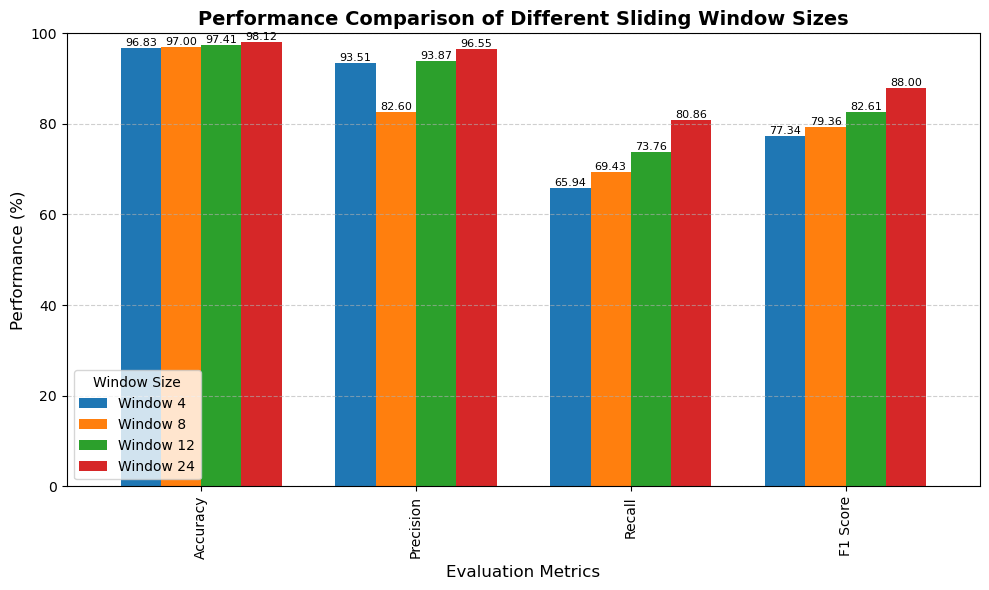

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Performance results
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Window 4":  [96.83, 93.51, 65.94, 77.34],
    "Window 8":  [97.00, 82.60, 69.43, 79.36],
    "Window 12": [97.41, 93.87, 73.76, 82.61],
    "Window 24": [98.12, 96.55, 80.86, 88.00]
})

print(results)

# Plot
ax = results.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6),
    width=0.75
)

plt.title("Performance Comparison of Different Sliding Window Sizes",
          fontsize=14,
          fontweight="bold")

plt.ylabel("Performance (%)", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)

plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Window Size")

# Show values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.tight_layout()

plt.show()

In [9]:
results = test_df.copy()

results["Predicted"] = y_pred

In [10]:
#########################################################
# CONTAMINATION SIZE GROUPS
#########################################################

def contamination_size(amount):

    if amount < 50:
        return "Small"

    elif amount < 100:
        return "Medium"

    else:
        return "Large"


results["Size"] = results["InjectionAmount"].apply(
    contamination_size
)

print(results[[
    "InjectionAmount",
    "Size",
    "Attack",
    "Predicted"
]].head())

       InjectionAmount    Size  Attack  Predicted
15173        80.522452  Medium       0          0
34823        22.131426   Small       0          0
49498       111.047491   Large       0          0
21968       115.521248   Large       1          1
6741         60.349391  Medium       0          0


# Contamination Evaluation

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics = []

for size in ["Small", "Medium", "Large"]:

    subset = results[
        results["Size"] == size
    ]

    accuracy = accuracy_score(
        subset["Attack"],
        subset["Predicted"]
    )

    precision = precision_score(
        subset["Attack"],
        subset["Predicted"],
        zero_division=0
    )

    recall = recall_score(
        subset["Attack"],
        subset["Predicted"],
        zero_division=0
    )

    f1 = f1_score(
        subset["Attack"],
        subset["Predicted"],
        zero_division=0
    )

    metrics.append([
        size,
        accuracy*100,
        precision*100,
        recall*100,
        f1*100
    ])

metrics_df = pd.DataFrame(
    metrics,
    columns=[
        "Size",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

print(metrics_df)
print(results["Size"].value_counts())

     Size   Accuracy  Precision     Recall   F1 Score
0   Small  96.284830  94.117647  66.666667  78.048780
1  Medium  97.041985  96.376812  60.180995  74.094708
2   Large  97.060625  91.401274  71.039604  79.944290
Size
Large     4899
Medium    3144
Small     1938
Name: count, dtype: int64


# Plotting Graph of Contamination Detection Sizes

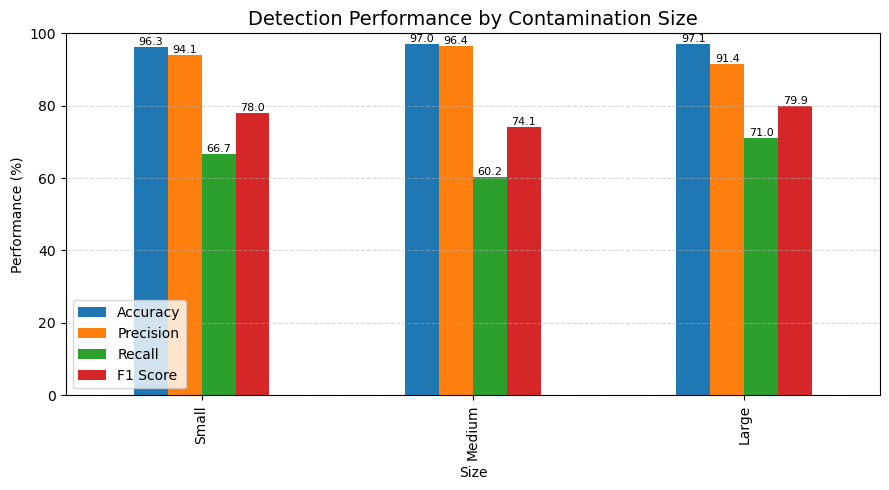

In [12]:
import matplotlib.pyplot as plt

ax = metrics_df.set_index("Size").plot(
    kind="bar",
    figsize=(9,5)
)

plt.title(
    "Detection Performance by Contamination Size",
    fontsize=14
)

plt.ylabel("Performance (%)")

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        fontsize=8
    )

plt.tight_layout()

plt.show()

# Detection by Injection Location

In [13]:
#########################################################
# LOCATION GROUPS
#########################################################

def location_group(node):

    node = int(node)

    if node <= 10:
        return "Near"

    elif node <= 22:
        return "Middle"

    else:
        return "Far"


results["Location"] = results["InjectionNode"].apply(location_group)

print(results[[
    "InjectionNode",
    "Location",
    "Attack",
    "Predicted"
]].head())

       InjectionNode Location  Attack  Predicted
15173             18   Middle       0          0
34823             31      Far       0          0
49498             28      Far       0          0
21968             10     Near       1          1
6741              29      Far       0          0


# Detection by Injection Location Evaluation

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

location_metrics = []

for location in ["Near", "Middle", "Far"]:

    subset = results[
        results["Location"] == location
    ]

    location_metrics.append({

        "Location": location,

        "Accuracy": accuracy_score(
            subset["Attack"],
            subset["Predicted"]
        ) * 100,

        "Precision": precision_score(
            subset["Attack"],
            subset["Predicted"],
            zero_division=0
        ) * 100,

        "Recall": recall_score(
            subset["Attack"],
            subset["Predicted"],
            zero_division=0
        ) * 100,

        "F1 Score": f1_score(
            subset["Attack"],
            subset["Predicted"],
            zero_division=0
        ) * 100
    })

location_df = pd.DataFrame(location_metrics)

print(location_df)

  Location   Accuracy  Precision     Recall   F1 Score
0     Near  97.362013  99.056604  76.923077  86.597938
1   Middle  96.755408  93.750000  60.885609  73.825503
2      Far  96.752749  86.500000  63.369963  73.150106


# Detection by Injection Location Graph Plotting


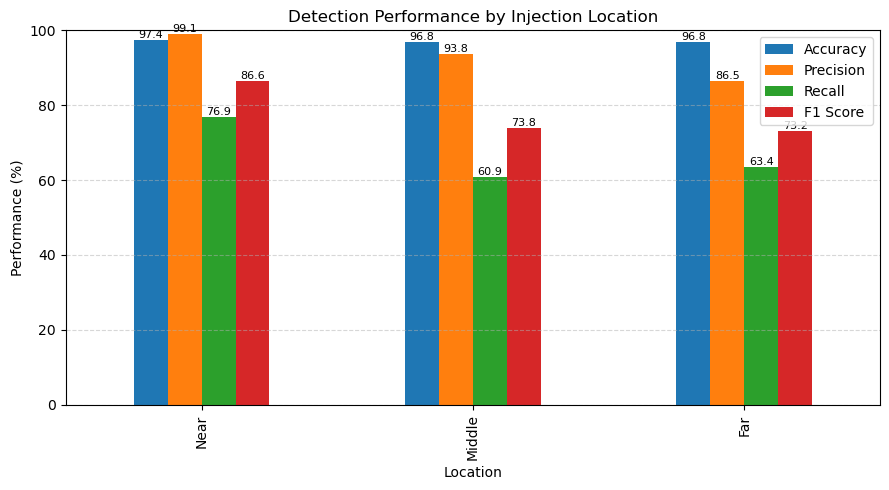

In [15]:
import matplotlib.pyplot as plt

ax = location_df.set_index("Location").plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Detection Performance by Injection Location")

plt.ylabel("Performance (%)")

plt.ylim(0,100)

plt.grid(axis="y", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8)

plt.tight_layout()

plt.show()

# Performance Comparision of Sliding Windows (4, 8, 12, 24)

      Metric  Window 4  Window 8  Window 12  Window 24
0   Accuracy     95.62     96.12      96.25      97.77
1  Precision     87.42     88.70      88.11      92.80
2     Recall     61.51     66.95      69.51      80.26
3   F1 Score     72.22     76.31      77.71      86.08


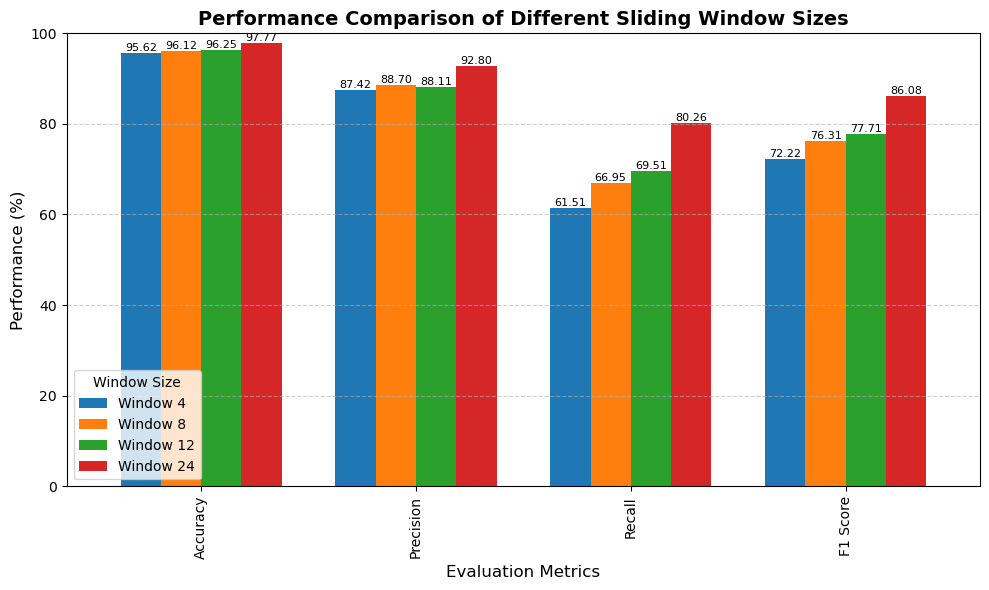

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Performance results
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Window 4":  [95.62, 87.42, 61.51, 72.22],
    "Window 8":  [96.12, 88.70, 66.95, 76.31],
    "Window 12": [96.25, 88.11, 69.51, 77.71],
    "Window 24": [97.77, 92.80, 80.26, 86.08]
})

print(results)

# Plot
ax = results.set_index("Metric").plot(
    kind="bar",
    figsize=(10,6),
    width=0.75
)

plt.title("Performance Comparison of Different Sliding Window Sizes",
          fontsize=14,
          fontweight="bold")

plt.ylabel("Performance (%)", fontsize=12)
plt.xlabel("Evaluation Metrics", fontsize=12)

plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Window Size")

# Show values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.tight_layout()

plt.show()

# Confusion Matrix

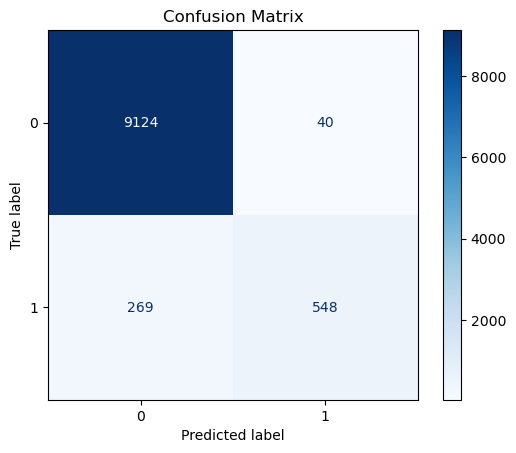

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Feature Importance

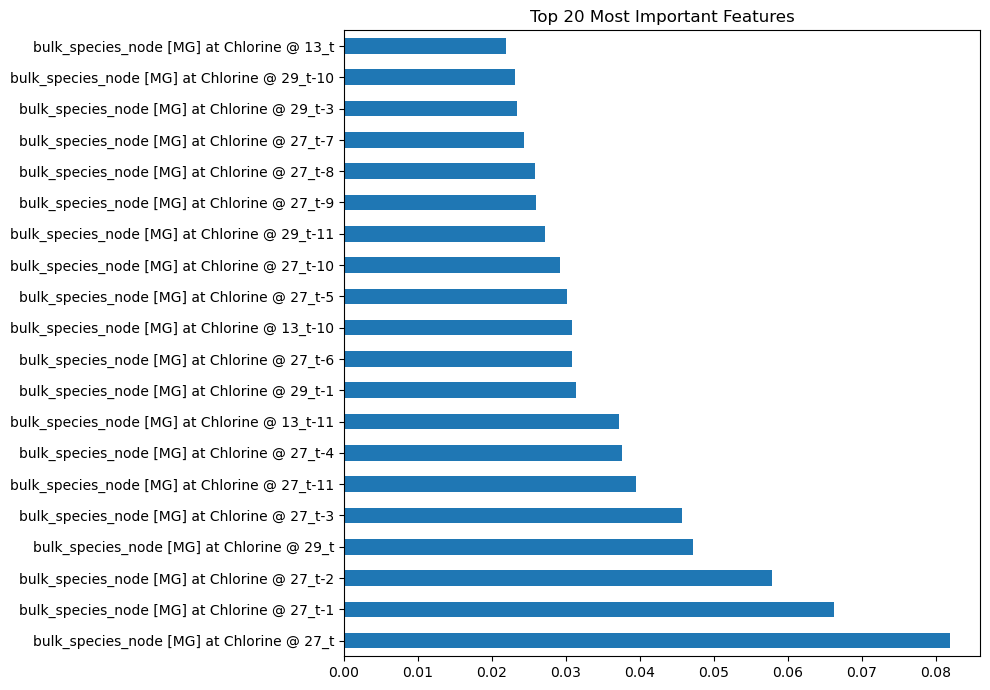

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(10,7))

importance.plot(kind="barh")

plt.title("Top 20 Most Important Features")

plt.tight_layout()

plt.show()

# ROC CURVE 

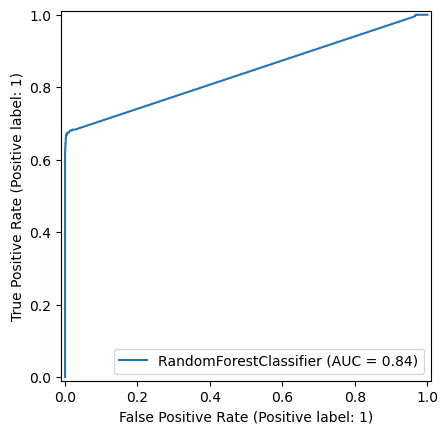

In [19]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

# PR CURVE

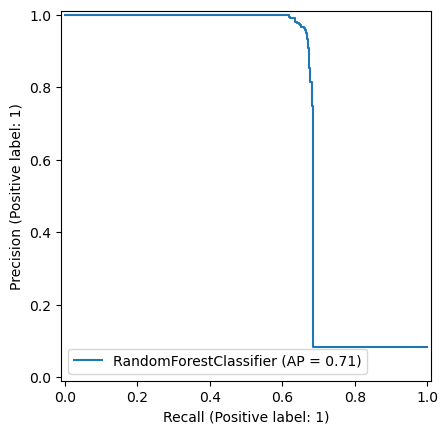

In [20]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()